# Resumen de Fase 1 — Cierre de recolección de datos

**Proyecto:** Predicción de Producción de Limón en el Perú
**Fase:** 1 — Recolección, limpieza y consolidación de fuentes
**Tipo:** Checkpoint de cierre (el EDA completo vive en Fase 2)

Este notebook verifica la existencia, cobertura temporal y alineación de rangos
de las **5 fuentes finales** de Fase 1 antes de pasar a
`notebooks/fase2_features/`:

| # | Fuente | Archivo |
|---|--------|---------|
| 1 | MIDAGRI — Limón Sutil (nacional mensual) | `v2_reentrenamiento/data/interim/limon_sutil_nacional_mensual.csv` |
| 2 | MIDAGRI — Limón Dulce (nacional mensual) | `v2_reentrenamiento/data/interim/limon_dulce_nacional_mensual.csv` |
| 3 | NASA POWER (clima por provincia) | `v2_reentrenamiento/data/raw/nasa_power/por_provincia/clima_nasa_power_2016_2025.csv` |
| 4 | INDECI (emergencias limpias) | `v2_reentrenamiento/data/interim/indeci_limpio_2016_2025.csv` |
| 5 | Noticias Agraria.pe (corpus v2) | `v2_reentrenamiento/data/interim/noticias/corpus_agronegocios_2016_2025.csv` |

---


## 1. Configuración inicial y carga de fuentes

In [1]:
import os, sys, json, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

# Navegar a la raiz del proyecto
while not os.path.exists('v2_reentrenamiento/data/interim'):
    os.chdir('..')

BASE_SRC = 'v2_reentrenamiento/data'
print('Raiz del proyecto:', os.getcwd())


Raiz del proyecto: C:\Machine-learming\Machine-Learning-Multimodal--Agro-NLP-Clima-


In [2]:
FUENTES = {
    'MIDAGRI Sutil (nacional mensual)': f'{BASE_SRC}/interim/limon_sutil_nacional_mensual.csv',
    'MIDAGRI Dulce (nacional mensual)': f'{BASE_SRC}/interim/limon_dulce_nacional_mensual.csv',
    'NASA POWER (clima provincial)':    f'{BASE_SRC}/raw/nasa_power/por_provincia/clima_nasa_power_2016_2025.csv',
    'INDECI (emergencias limpias)':     f'{BASE_SRC}/interim/indeci_limpio_2016_2025.csv',
    'Noticias Agraria.pe (corpus v2)':  f'{BASE_SRC}/interim/noticias/corpus_agronegocios_2016_2025.csv',
}

datasets = {}
for nombre, ruta in FUENTES.items():
    existe = os.path.exists(ruta)
    filas = ncols = 0
    rango = '--'
    if existe:
        df = pd.read_csv(ruta)
        filas, ncols = df.shape
        datasets[nombre] = df
    print(f'{"[OK]" if existe else "[FALTANTE]"} {nombre}  [{ruta}]')
    print(f'    filas={filas}  columnas={ncols}')


[OK] MIDAGRI Sutil (nacional mensual)  [v2_reentrenamiento/data/interim/limon_sutil_nacional_mensual.csv]
    filas=120  columnas=5
[OK] MIDAGRI Dulce (nacional mensual)  [v2_reentrenamiento/data/interim/limon_dulce_nacional_mensual.csv]
    filas=120  columnas=5
[OK] NASA POWER (clima provincial)  [v2_reentrenamiento/data/raw/nasa_power/por_provincia/clima_nasa_power_2016_2025.csv]
    filas=13080  columnas=12
[OK] INDECI (emergencias limpias)  [v2_reentrenamiento/data/interim/indeci_limpio_2016_2025.csv]
    filas=12840  columnas=10
[OK] Noticias Agraria.pe (corpus v2)  [v2_reentrenamiento/data/interim/noticias/corpus_agronegocios_2016_2025.csv]
    filas=2883  columnas=6


## 2. Verificación de existencia y filas

In [3]:
resumen = []
for nombre, df in datasets.items():
    resumen.append({'Fuente': nombre, 'Filas': df.shape[0], 'Columnas': df.shape[1]})
pd.DataFrame(resumen)


,Fuente,Filas,Columnas
0,MIDAGRI Sutil (nacional mensual),120,5
1,MIDAGRI Dulce (nacional mensual),120,5
2,NASA POWER (clima provincial),13080,12
3,INDECI (emergencias limpias),12840,10
4,Noticias Agraria.pe (corpus v2),2883,6


## 3. Cobertura temporal por fuente

Cada fuente se normaliza a un período `YYYY-MM` para comparar rangos.
**El objetivo es detectar visualmente cualquier desalineación** entre fuentes
antes de construir las features de Fase 2.


In [4]:
def mes_key(df, hay_fecha=True):
    if hay_fecha:
        return pd.to_datetime(df['fecha'], errors='coerce').dt.strftime('%Y-%m')
    return (df['anio'].astype(int).astype(str) + '-' + df['mes'].astype(int).astype(str).str.zfill(2))

# Normalizar 'anio'/'año' a 'anio' para las fuentes mensuales MIDAGRI/INDECI
for nombre in ['MIDAGRI Sutil (nacional mensual)', 'MIDAGRI Dulce (nacional mensual)']:
    df = datasets[nombre]
    df.rename(columns={'año': 'anio'}, inplace=True)

cobertura = pd.DataFrame({
    'Fuente': [],
    'Min': [], 'Max': [], 'Meses cubiertos': [], 'Meses esperados': [], 'Cobertura %': [],
})

cobertura_list = []
for nombre, df in datasets.items():
    if nombre.startswith('Noticias'):
        serie = mes_key(df, hay_fecha=True)
    elif nombre.startswith('NASA'):
        serie = pd.to_datetime(df['DATE']).dt.strftime('%Y-%m')
    else:
        serie = mes_key(df, hay_fecha=False)
    unicos = set(serie.dropna())
    todos = pd.date_range('2016-01', '2025-12', freq='MS').strftime('%Y-%m')
    faltantes = [m for m in todos if m not in unicos]
    cobertura_list.append({
        'Fuente': nombre,
        'Min': min(unicos), 'Max': max(unicos),
        'Meses cubiertos': len(unicos), 'Meses esperados': len(todos),
        'Cobertura %': round(100 * len(unicos) / len(todos), 1),
        'Huecos (meses sin datos)': ', '.join(faltantes) if faltantes else '—',
    })
cobertura = pd.DataFrame(cobertura_list)
cobertura


,Fuente,Min,Max,Meses cubiertos,Meses esperados,Cobertura %,Huecos (meses sin datos)
0,MIDAGRI Sutil (nacional mensual),2016-01,2025-12,120,120,100.0,—
1,MIDAGRI Dulce (nacional mensual),2016-01,2025-12,120,120,100.0,—
2,NASA POWER (clima provincial),2016-01,2025-12,120,120,100.0,—
3,INDECI (emergencias limpias),2016-01,2025-12,120,120,100.0,—
4,Noticias Agraria.pe (corpus v2),2016-03,2025-12,118,120,98.3,"2016-01, 2016-02"


### 3.1 Gaps visibles por fuente

- Midagri Sutil/Dulce, NASA e INDECI cubren **120/120 meses** (2016-01 a 2025-12).
- **Noticias** cubre solo **118/120** — faltan 2016-01 y 2016-02 (documentado en
  `DECISIONES_METODOLOGICAS.md`). Impacto: `avg_sentiment=0`/`n_noticias=0` en
  esos 2 meses del dataset maestro.


## 4. Gráficos exploratorios de cierre

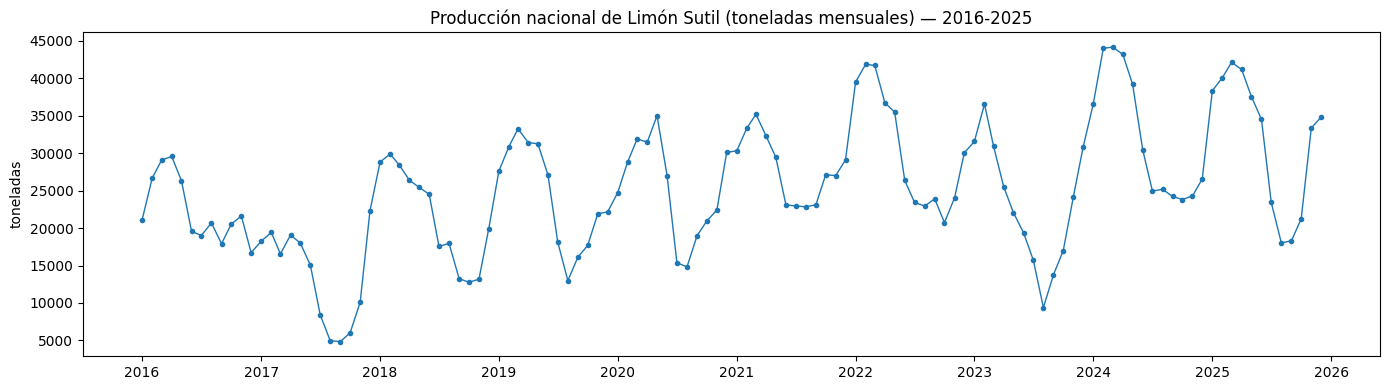

In [5]:
sutil = datasets['MIDAGRI Sutil (nacional mensual)'].sort_values(['anio', 'mes'])
sutil['periodo'] = sutil['anio'].astype(int).astype(str) + '-' + sutil['mes'].astype(int).astype(str).str.zfill(2)
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(pd.period_range('2016-01', periods=len(sutil), freq='M').to_timestamp(), sutil['produccion_t_nacional'], marker='.', lw=1)
ax.set_title('Producción nacional de Limón Sutil (toneladas mensuales) — 2016-2025')
ax.set_ylabel('toneladas')
plt.tight_layout()
plt.show()


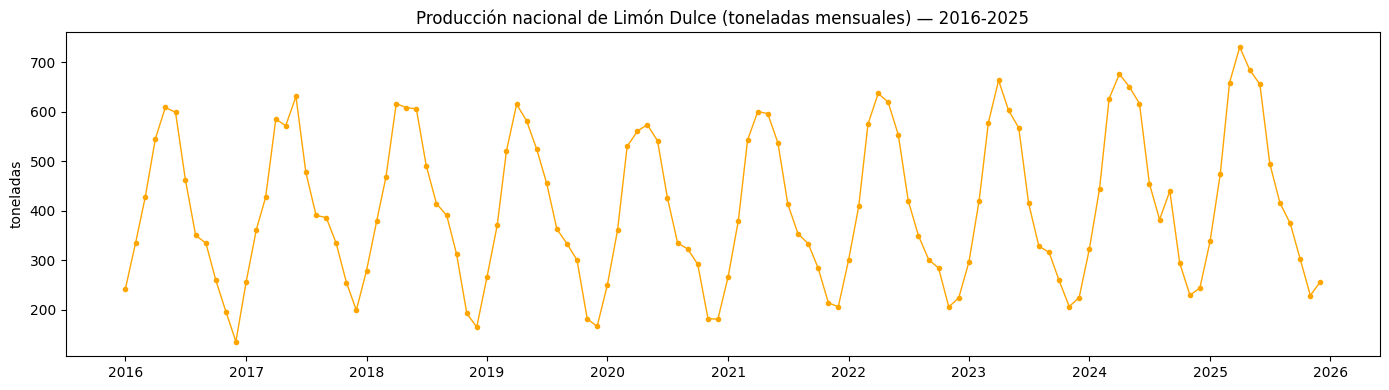

In [6]:
dulce = datasets['MIDAGRI Dulce (nacional mensual)'].sort_values(['anio', 'mes'])
dulce['periodo'] = dulce['anio'].astype(int).astype(str) + '-' + dulce['mes'].astype(int).astype(str).str.zfill(2)
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(pd.period_range('2016-01', periods=len(dulce), freq='M').to_timestamp(), dulce['produccion_t_nacional'], marker='.', lw=1, color='orange')
ax.set_title('Producción nacional de Limón Dulce (toneladas mensuales) — 2016-2025')
ax.set_ylabel('toneladas')
plt.tight_layout()
plt.show()


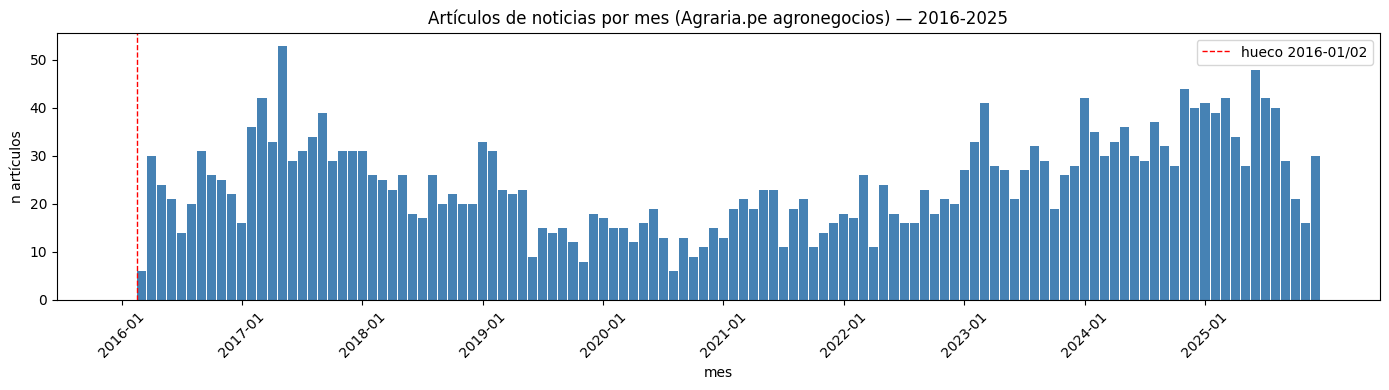

Meses con 0 noticias: 2 | total artículos: 2883


In [7]:
noticias = datasets['Noticias Agraria.pe (corpus v2)'].copy()
noticias['periodo'] = pd.to_datetime(noticias['fecha'], errors='coerce').dt.strftime('%Y-%m')
conteo_mensual = noticias.groupby('periodo').size()
idx = pd.period_range('2016-01', '2025-12', freq='M').strftime('%Y-%m')
conteo_mensual = conteo_mensual.reindex(idx, fill_value=0)

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(idx, conteo_mensual.values, width=0.9, color='steelblue')
ax.axvline(x=1.5, color='red', lw=1, ls='--', label='hueco 2016-01/02')
ax.set_title('Artículos de noticias por mes (Agraria.pe agronegocios) — 2016-2025')
ax.set_ylabel('n artículos')
ax.set_xlabel('mes')
ax.legend()
plt.xticks(range(0, 120, 12), idx[::12], rotation=45)
plt.tight_layout()
plt.show()

print(f'Meses con 0 noticias: {(conteo_mensual == 0).sum()} | total artículos: {conteo_mensual.sum()}')


In [8]:
print('=== CHECKPOINT DE CIERRE DE FASE 1 ===')
print()
for _, row in cobertura.iterrows():
    print(f'{row["Fuente"]}')
    print(f'   filas={datasets[row["Fuente"]].shape[0]} | rango {row["Min"]} -> {row["Max"]} | cobertura {row["Cobertura %"]}%')
    print()
print('ALINEACION DE RANGOS: 4/5 fuentes cubren 2016-01..2025-12 (120 meses).')
print('Noticias: 118/120 meses - huecos 2016-01/02 (ver DECISIONES_METODOLOGICAS.md).')
print('FASE 1 CERRADA. LISTA PARA FASE 2 -> notebooks/fase2_features/')


=== CHECKPOINT DE CIERRE DE FASE 1 ===

MIDAGRI Sutil (nacional mensual)
   filas=120 | rango 2016-01 -> 2025-12 | cobertura 100.0%

MIDAGRI Dulce (nacional mensual)
   filas=120 | rango 2016-01 -> 2025-12 | cobertura 100.0%

NASA POWER (clima provincial)
   filas=13080 | rango 2016-01 -> 2025-12 | cobertura 100.0%

INDECI (emergencias limpias)
   filas=12840 | rango 2016-01 -> 2025-12 | cobertura 100.0%

Noticias Agraria.pe (corpus v2)
   filas=2883 | rango 2016-03 -> 2025-12 | cobertura 98.3%

ALINEACION DE RANGOS: 4/5 fuentes cubren 2016-01..2025-12 (120 meses).
Noticias: 118/120 meses - huecos 2016-01/02 (ver DECISIONES_METODOLOGICAS.md).
FASE 1 CERRADA. LISTA PARA FASE 2 -> notebooks/fase2_features/
